In [62]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import os

## Load dataset

In [63]:
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "database" / "gojek" / "cleaned_gojek_data.csv"
print(f"Data directory: {DATA_DIR}")

# Load the dataset
pd.set_option('display.max_columns', None)  # Show all columns
df = pd.read_csv(DATA_DIR)
df

Data directory: /Users/miftahhadiyannoor/Documents/Gojek-Project/database/gojek/cleaned_gojek_data.csv


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,414000.0,23.72,4.3,4.5,Debit Card
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,1.0,Vehicle Breakdown,237000.0,5.73,4.3,4.5,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,627000.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,416000.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,475000.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,333000.0,45.54,4.1,3.7,UPI


In [64]:
df.columns.tolist()

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method']

In [65]:
# Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.time

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           150000 non-null  float64       
 9   Avg CTAT                           150000 non-null  float64       
 10  Cancelled Rides by C

## 👨‍💻 Goals project

### Build taxi tracking for similar in tracking ride
 * #### Maps tracking - Google maps
### Machine learning to ensure the project is enterprise production for better learnt
* #### Cluster fast way tracks

## Feature Engineering

In [66]:
reason_data = ['Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Driver Ratings',
 'Customer Rating',]

reason_data_df = df[reason_data]
reason_data_df.head()

,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Driver Ratings,Customer Rating
0,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.3,4.5
1,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,1.0,Vehicle Breakdown,4.3,4.5
2,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.9,4.9
3,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.6,5.0
4,No Reason Provided,No Reason Provided,No Reason Provided,No Reason Provided,0.0,No Reason Provided,4.1,4.3


## Define Reason Pools

In [67]:
import random

customer_cancel_reasons = [
    "Changed Mind",
    "Booked by Mistake",
    "Driver Taking Too Long",
    "Found Alternative",
    "Wrong Pickup Location",
    "No Reason Provided"
]

driver_cancel_reasons = [
    "Personal Issue",
    "Vehicle Breakdown",
    "Traffic Issue",
    "Customer Unreachable",
    "Wrong Location",
    "No Reason Provided"
]

incomplete_reasons = [
    "Vehicle Breakdown",
    "Ride Cancelled Midway",
    "Customer Issue",
    "App Error",
    "Route Problem",
    "No Reason Provided"
]

In [68]:
def generate_reason_v2(driver_rating, customer_rating):
    
    # CASE 1: Both good → clean ride
    if driver_rating >= 4.7 and customer_rating >= 4.7:
        return {
            'Cancelled Rides by Customer': "No Cancellation",
            'Reason for cancelling by Customer': "No Cancellation",
            'Cancelled Rides by Driver': "No Cancellation",
            'Driver Cancellation Reason': "No Cancellation",
            'Incomplete Rides': 0.0,
            'Incomplete Rides Reason': "No Cancellation"
        }
    
    # CASE 2: Good driver, bad customer → customer problems
    elif driver_rating >= 4.5 and customer_rating < 4.2:
        return {
            'Cancelled Rides by Customer': "Cancelled, the service is bad",
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': "No Cancellation",
            'Driver Cancellation Reason': "No Cancellation",
            'Incomplete Rides': random.choice([0.0, 1.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 3: Bad driver, good customer → driver problems
    elif driver_rating < 4.2 and customer_rating >= 4.5:
        return {
            'Cancelled Rides by Customer': "No Cancellation",
            'Reason for cancelling by Customer': "No Cancellation",
            'Cancelled Rides by Driver': "Cancelled",
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([1.0, 2.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 4: Both bad → chaos 😄
    elif driver_rating < 4.2 and customer_rating < 4.2:
        return {
            'Cancelled Rides by Customer': "Cancelled, the service is bad",
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': "Cancelled",
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([1.0, 2.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
    # CASE 5: mixed ratings → random reasons
    else:
        return {
            'Cancelled Rides by Customer': random.choice(["No Cancellation", "Cancelled"]),
            'Reason for cancelling by Customer': random.choice(customer_cancel_reasons),
            'Cancelled Rides by Driver': random.choice(["No Cancellation", "Cancelled"]),
            'Driver Cancellation Reason': random.choice(driver_cancel_reasons),
            'Incomplete Rides': random.choice([0.0, 1.0]),
            'Incomplete Rides Reason': random.choice(incomplete_reasons)
        }
    
# Generate new reason columns based on ratings
generated = df.apply(
    lambda row: generate_reason_v2(row['Driver Ratings'], row['Customer Rating']), axis=1
)
generated_df = pd.DataFrame(list(generated))

In [69]:
generated_df

,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason
0,Cancelled,No Reason Provided,Cancelled,Personal Issue,0.0,Customer Issue
1,No Cancellation,Wrong Pickup Location,Cancelled,Personal Issue,0.0,Route Problem
2,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
3,Cancelled,Driver Taking Too Long,Cancelled,Customer Unreachable,0.0,App Error
4,No Cancellation,Driver Taking Too Long,No Cancellation,No Reason Provided,1.0,Vehicle Breakdown
...,...,...,...,...,...,...
149995,"Cancelled, the service is bad",Changed Mind,Cancelled,Traffic Issue,2.0,No Reason Provided
149996,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
149997,No Cancellation,Booked by Mistake,Cancelled,No Reason Provided,1.0,Customer Issue
149998,"Cancelled, the service is bad",Driver Taking Too Long,Cancelled,Wrong Location,2.0,Customer Issue


In [70]:
# Merge back to original dataframe
df = df.drop(columns=[
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
], errors='ignore')

df = pd.concat([df, generated_df], axis=1)
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,414000.0,23.72,4.3,4.5,Debit Card,Cancelled,No Reason Provided,Cancelled,Personal Issue,0.0,Customer Issue
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237000.0,5.73,4.3,4.5,UPI,No Cancellation,Wrong Pickup Location,Cancelled,Personal Issue,0.0,Route Problem
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627000.0,13.58,4.9,4.9,Debit Card,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416000.0,34.02,4.6,5.0,UPI,Cancelled,Driver Taking Too Long,Cancelled,Customer Unreachable,0.0,App Error
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737.0,48.21,4.1,4.3,UPI,No Cancellation,Driver Taking Too Long,No Cancellation,No Reason Provided,1.0,Vehicle Breakdown


## Replace data -> Drop location

In [71]:
jakarta_kelurahan = [
    # Jakarta Pusat (44)
    "Gambir", "Kebon Kelapa", "Petojo Utara", "Duri Pulo", "Cideng", "Petojo Selatan",
    "Bendungan Hilir", "Karet Tengsin", "Kebon Melati", "Kebon Kacang", "Kampung Bali",
    "Petamburan", "Gelora", "Menteng", "Pegangsaan", "Cikini", "Kebon Sirih", "Gondangdia",
    "Senen", "Kwitang", "Kenari", "Paseban", "Kramat", "Bungur",
    "Cempaka Putih Timur", "Cempaka Putih Barat", "Rawasari",
    "Galur", "Tanah Tinggi", "Kampung Rawa", "Johar Baru",
    "Gunung Sahari Selatan", "Kemayoran", "Kebon Kosong", "Cempaka Baru",
    "Harapan Mulya", "Sumur Batu", "Serdang", "Utan Panjang",
    "Pasar Baru", "Gunung Sahari Utara", "Mangga Dua Selatan", "Karang Anyar", "Kartini",
 
    # Jakarta Barat (52)
    "Pinangsia", "Glodok", "Keagungan", "Krukut", "Tamansari", "Maphar", "Tangki",
    "Mangga Besar", "Tanah Sareal", "Tambora", "Duri Selatan", "Duri Utara", "Kali Anyar",
    "Pekojan", "Roa Malaka", "Angke", "Jembatan Lima", "Jembatan Besi", "Duri Kepa",
    "Wijaya Kusuma", "Tanjung Duren Utara", "Tanjung Duren Selatan", "Grogol", "Tomang",
    "Jelambar", "Jelambar Baru", "Kedaung Kali Angke", "Cengkareng Barat", "Cengkareng Timur",
    "Kapuk", "Rawa Buaya", "Duri Kosambi", "Kembangan Utara", "Kembangan Selatan",
    "Joglo", "Srengseng", "Meruya Utara", "Meruya Selatan", "Palmerah", "Kemanggisan",
    "Slipi", "Kota Bambu Utara", "Kota Bambu Selatan", "Sukabumi Utara", "Sukabumi Selatan",
    "Kelapa Dua", "Tegal Alur", "Kamal", "Pegadungan", "Kalideres", "Semanan", "Batu Ceper",
 
    # Jakarta Timur (60)
    "Matraman", "Palmeriam", "Kebon Manggis", "Pisangan Baru", "Utan Kayu Utara",
    "Utan Kayu Selatan", "Cipinang Muara", "Cipinang Besar Selatan", "Cipinang Besar Utara",
    "Cipinang Cempedak", "Jatinegara", "Rawa Bunga", "Bali Mester", "Kampung Melayu",
    "Bidara Cina", "Cawang", "Cililitan", "Kramat Jati", "Batu Ampar", "Balekambang",
    "Dukuh", "Tengah", "Gedong", "Cijantung", "Kalisari", "Pekayon",
    "Pasar Rebo", "Susukan", "Ciracas", "Rambutan", "Cibubur",
    "Makasar", "Pinang Ranti", "Cipinang Melayu", "Halim Perdana Kusuma", "Kebon Pala",
    "Penggilingan", "Cakung Barat", "Cakung Timur", "Pulo Gebang", "Ujung Menteng",
    "Rawa Terate", "Pisangan Timur", "Kayu Putih", "Rawamangun", "Jati",
    "Pondok Bambu", "Duren Sawit", "Pondok Kelapa", "Malaka Sari", "Malaka Jaya",
    "Pondok Kopi", "Lubang Buaya", "Cipayung", "Setu", "Bambu Apus",
    "Cilangkap", "Munjul", "Pondok Ranggon", "Kelapa Gading Barat", "Kelapa Gading Timur",
 
    # Jakarta Selatan (58)
    "Tebet Barat", "Tebet Timur", "Kebon Baru", "Bukit Duri", "Manggarai",
    "Manggarai Selatan", "Menteng Dalam", "Menteng Atas", "Pasar Manggis", "Guntur",
    "Setiabudi", "Karet Semanggi", "Karet Kuningan", "Kuningan Timur",
    "Pancoran", "Duren Tiga", "Kalibata", "Pengadegan", "Cikoko",
    "Ciganjur", "Jagakarsa", "Srengseng Sawah", "Tanjung Barat", "Lenteng Agung",
    "Pasar Minggu", "Kebagusan", "Ragunan", "Cilandak Timur", "Jati Padang",
    "Pejaten Timur", "Pejaten Barat", "Kemang", "Bangka", "Pela Mampang",
    "Tegal Parang", "Mampang Prapatan", "Kuningan Barat",
    "Kebayoran Lama Utara", "Kebayoran Lama Selatan", "Grogol Selatan", "Grogol Utara",
    "Pesanggrahan", "Bintaro", "Ulujami", "Cipete Selatan", "Cipete Utara",
    "Petogogan", "Melawai", "Kramat Pela", "Kebayoran Baru",
    "Gandaria Selatan", "Gandaria Utara", "Cipedak", "Cilandak Barat",
    "Lebak Bulus", "Pondok Labu", "Fatmawati", "Pondok Pinang",
 
    # Jakarta Utara (29)
    "Penjaringan", "Pejagalan", "Pluit", "Kamal Muara", "Kapuk Muara", "Tugu Utara",
    "Tugu Selatan", "Semper Barat", "Semper Timur", "Rawa Badak Utara", "Rawa Badak Selatan",
    "Lagoa", "Koja", "Tanjung Priok", "Sunter Agung", "Sunter Jaya", "Papanggo",
    "Sungai Bambu", "Kebon Bawang", "Warakas", "Pademangan Barat", "Pademangan Timur",
    "Ancol", "Kali Baru", "Cilincing", "Sukapura", "Marunda", "Rorotan", "Pulo Gadung",
]

# Remove duplicates while preserving order
jakarta_kelurahan = list(dict.fromkeys(jakarta_kelurahan))
print(f"Total unique kelurahan in Jakarta: {len(jakarta_kelurahan)}")

Total unique kelurahan in Jakarta: 244


In [72]:
# Get all unique original locations
drop_locations = df['Drop Location'].unique().tolist()
pickup_locations = df['Pickup Location'].unique().tolist()

# Create a mapping dict: each original locations -> a Jakarta kelurahan (randomly assigned)
random.seed(42)  # For reproducibility
shuffled_jakarta = jakarta_kelurahan.copy()
random.shuffle(shuffled_jakarta)

# For drop locations
drop_location_map = {}
for i, loc in enumerate(drop_locations):
    drop_location_map[loc] = shuffled_jakarta[i % len(shuffled_jakarta)]

# For pickup locations
shuffled_jakarta_pickup = jakarta_kelurahan.copy()
random.shuffle(shuffled_jakarta_pickup)

pickup_location_map = {}
for i, loc in enumerate(pickup_locations):
    pickup_location_map[loc] = shuffled_jakarta_pickup[i % len(shuffled_jakarta_pickup)]

# Apply mappings
df['Drop Location'] = df['Drop Location'].map(drop_location_map)
df['Pickup Location'] = df['Pickup Location'].map(pickup_location_map)

print("Sample of mapped drop locations:")
print(df['Drop Location'].unique()[:10])

print("\nSample of mapped pickup locations:")
print(df['Pickup Location'].unique()[:10])

Sample of mapped drop locations:
['Glodok' 'Kramat Jati' 'Kebon Kacang' 'Kota Bambu Utara'
 'Cipinang Cempedak' 'Bintaro' 'Pondok Labu' 'Penggilingan' 'Pela Mampang'
 'Pinangsia']

Sample of mapped pickup locations:
['Tanah Tinggi' 'Cipinang Melayu' 'Mangga Dua Selatan' 'Glodok'
 'Sunter Jaya' 'Semanan' 'Pesanggrahan' 'Rambutan' 'Sunter Agung'
 'Pondok Ranggon']


In [73]:
df['Drop Location'].sample(30)

71837              Menteng Atas
136420          Utan Kayu Utara
122980           Meruya Selatan
112457            Jelambar Baru
111629                  Bintaro
1215                      Lagoa
88416            Cilandak Barat
126240           Kuningan Timur
39625                  Kalisari
135039              Kramat Jati
137234              Kemanggisan
24841                 Fatmawati
59759                 Cilincing
74951               Pondok Labu
44797                 Cilangkap
39615                 Tamansari
20453                Kebon Pala
44409              Duri Selatan
20187            Cilandak Barat
50880              Duri Selatan
79927              Cempaka Baru
32085     Tanjung Duren Selatan
11155               Pulo Gebang
81273                Rawa Buaya
78810                     Senen
30237       Kelapa Gading Barat
38735             Wijaya Kusuma
33369               Kramat Jati
101398     Cipinang Besar Utara
97397       Kelapa Gading Timur
Name: Drop Location, dtype: object

In [74]:
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str))
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek

In [75]:
# Encode locations
from sklearn.preprocessing import LabelEncoder

le_pickup = LabelEncoder()
le_drop = LabelEncoder()

df['Pickup Encoded'] = le_pickup.fit_transform(df['Pickup Location'])
df['Drop Encoded'] = le_drop.fit_transform(df['Drop Location'])

## 🚀 Cluster fast route patterns

In [76]:
# Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df['route_cluster'] = kmeans.fit_predict(df[['Pickup Encoded', 'Drop Encoded', 'hour']])

## 🧠 Feature Engineering 

In [77]:
# 1a. Distance-based features
df['distance_per_hour'] = df['Ride Distance'] / (df['hour'] + 1)
df['log_distance'] = np.log1p(df['Ride Distance'])

# 1b. Time-based features
df['is_peak_hour'] = df['hour'].apply(lambda h: 1 if h in [7,8,9,17,18,19,20] else 0)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = df['hour'].apply(lambda h: 1 if h >= 22 or h <= 5 else 0)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# 1c. Rating-based features
df['rating_diff'] = df['Driver Ratings'] - df['Customer Rating']
df['rating_product'] = df['Driver Ratings'] * df['Customer Rating']
df['avg_rating'] = (df['Driver Ratings'] + df['Customer Rating']) / 2
df['low_driver_rating'] = (df['Driver Ratings'] < 4.2).astype(int)
df['low_customer_rating'] = (df['Customer Rating'] < 4.2).astype(int)

# 1d. Route-level aggregated stats
route_stats = df.groupby(['Pickup Encoded', 'Drop Encoded']).agg(
    route_avg_ctat = ('Avg CTAT', 'mean'),
    route_avg_price = ('Booking Value', 'mean'),
    route_avg_distance = ('Ride Distance', 'mean'),
    route_count = ('Ride Distance', 'count')
).reset_index()

df = df.merge(route_stats, on=['Pickup Encoded', 'Drop Encoded'], how='left')

# Fill NaM from merge (routes with only 1 ride) with original values
df['route_avg_ctat'].fillna(df['Avg CTAT'].mean(), inplace=True)
df['route_avg_price'].fillna(df['Booking Value'].mean(), inplace=True)
df['route_avg_distance'].fillna(df['Ride Distance'].mean(), inplace=True)
df['route_count'].fillna(1, inplace=True)

In [78]:
features = [
    # Original features
    'Pickup Encoded',
    'Drop Encoded',
    'Ride Distance',
    'hour',
    'day_of_week',
    #'Driver Ratings',
    #'Customer Rating',
    'route_cluster',

    # New engineered features
    #'log_distance',
    #'distance_per_hour',
    'is_peak_hour',
    'is_weekend',
    #'is_night',
    'hour_sin',
    'hour_cos',
    'day_sin',
    'day_cos',
    #'rating_diff',
    #'rating_product',
    #'avg_rating',
    #'low_driver_rating',
    #'low_customer_rating',
    #'route_avg_ctat',
    #'route_avg_price',
    #'route_avg_distance',
    #'route_count',
]

X = df[features]

In [79]:
X

,Pickup Encoded,Drop Encoded,Ride Distance,hour,day_of_week,route_cluster,is_peak_hour,is_weekend,hour_sin,hour_cos,day_sin,day_cos
0,160,40,23.72,12,5,2,0,1,1.224647e-16,-1.000000e+00,-0.974928,-0.222521
1,24,86,5.73,18,4,0,1,0,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969
2,96,73,13.58,8,4,4,1,0,8.660254e-01,-5.000000e-01,-0.433884,-0.900969
3,31,85,34.02,17,0,0,1,0,-9.659258e-01,-2.588190e-01,0.000000,1.000000
4,157,28,48.21,22,0,2,0,0,-5.000000e-01,8.660254e-01,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,73,143,40.08,19,0,3,1,0,-9.659258e-01,2.588190e-01,0.000000,1.000000
149996,128,136,21.31,15,6,1,0,1,-7.071068e-01,-7.071068e-01,-0.781831,0.623490
149997,165,63,15.93,10,2,2,0,0,5.000000e-01,-8.660254e-01,0.974928,-0.222521
149998,71,19,45.54,7,5,4,1,1,9.659258e-01,-2.588190e-01,-0.974928,-0.222521


In [80]:
# Analyze cluster characteristics
df.groupby('route_cluster')[[
    'Ride Distance',
    'Avg CTAT',
    'Avg VTAT',
    'Booking Value'
]].mean()

,Ride Distance,Avg CTAT,Avg VTAT,Booking Value
route_cluster,,,,
0,24.389663,29.090674,8.409890,317413.633918
1,24.266986,28.997386,8.453963,315674.105577
2,24.415198,29.106769,8.467661,316294.214579
3,24.310150,29.048111,8.449909,315899.939524
4,24.377467,28.961894,8.441071,317403.957303


## Check data outliers

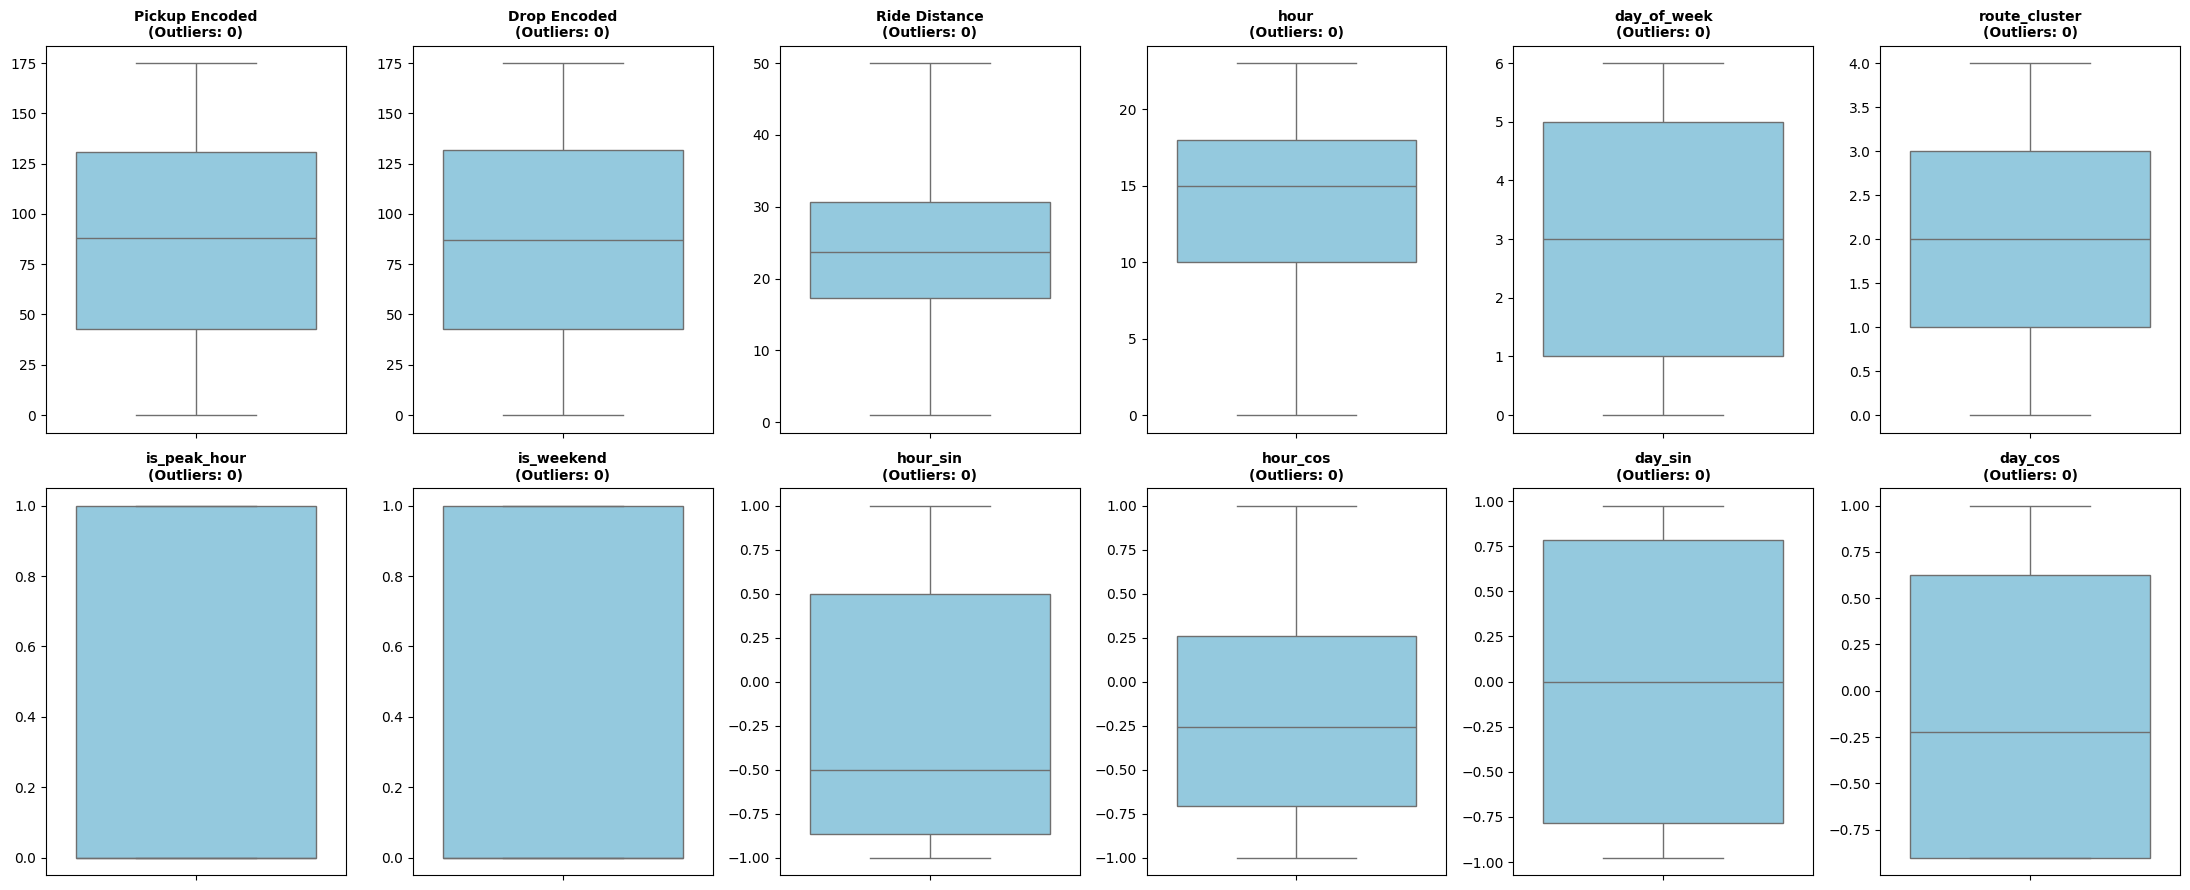

Total features: 12
Grid size: 2 × 6


In [81]:
# Boxplots with outlier detection
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def count_outliers(data, column):
    """Count outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data[column] < (Q1 - 1.5 * IQR)) | (data[column] > (Q3 + 1.5 * IQR))).sum()
    return outliers

n_features = len(features)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.boxplot(data=df, y=feature, ax=axes[idx], color='skyblue')
    
    # Count and display outliers
    outlier_count = count_outliers(df, feature)
    axes[idx].set_title(
        f"{feature}\n(Outliers: {outlier_count})", 
        fontsize=10, 
        fontweight='bold'
    )
    axes[idx].set_ylabel("")

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total features: {n_features}")
print(f"Grid size: {n_rows} × {n_cols}")

In [82]:
# Remove outliers with z-score
from scipy import stats

# IQR method
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
outlier_condition = ((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)
df_cleanded_iqr = df[~outlier_condition].reset_index(drop=True)

In [83]:
df_cleanded_iqr

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Datetime,hour,day_of_week,Pickup Encoded,Drop Encoded,route_cluster,distance_per_hour,log_distance,is_peak_hour,is_weekend,is_night,hour_sin,hour_cos,day_sin,day_cos,rating_diff,rating_product,avg_rating,low_driver_rating,low_customer_rating,route_avg_ctat,route_avg_price,route_avg_distance,route_count
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Tanah Tinggi,Glodok,8.3,28.8,414000.0,23.72,4.3,4.5,Debit Card,Cancelled,No Reason Provided,Cancelled,Personal Issue,0.0,Customer Issue,2024-03-23 12:29:38,12,5,160,40,2,1.824615,3.207613,0,1,0,1.224647e-16,-1.000000e+00,-0.974928,-0.222521,-0.2,19.35,4.40,0,0,27.450000,272728.500000,27.262500,4
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Cipinang Melayu,Kramat Jati,4.9,14.0,237000.0,5.73,4.3,4.5,UPI,No Cancellation,Wrong Pickup Location,Cancelled,Personal Issue,0.0,Route Problem,2024-11-29 18:01:39,18,4,24,86,0,0.301579,1.906575,1,0,0,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969,-0.2,19.35,4.40,0,0,15.450000,257000.000000,25.220000,2
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Mangga Dua Selatan,Kebon Kacang,13.4,25.8,627000.0,13.58,4.9,4.9,Debit Card,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation,2024-08-23 08:56:10,8,4,96,73,4,1.508889,2.679651,1,0,0,8.660254e-01,-5.000000e-01,-0.433884,-0.900969,0.0,24.01,4.90,0,0,31.511111,309878.111111,24.376667,9
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Glodok,Kota Bambu Utara,13.1,28.5,416000.0,34.02,4.6,5.0,UPI,Cancelled,Driver Taking Too Long,Cancelled,Customer Unreachable,0.0,App Error,2024-10-21 17:17:25,17,0,31,85,0,1.890000,3.555919,1,0,0,-9.659258e-01,-2.588190e-01,0.000000,1.000000,-0.4,23.00,4.80,0,0,22.812500,318990.500000,21.186250,8
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Sunter Jaya,Cipinang Cempedak,5.3,19.6,737.0,48.21,4.1,4.3,UPI,No Cancellation,Driver Taking Too Long,No Cancellation,No Reason Provided,1.0,Vehicle Breakdown,2024-09-16 22:08:00,22,0,157,28,2,2.096087,3.896097,0,0,1,-5.000000e-01,8.660254e-01,0.000000,1.000000,-0.2,17.63,4.20,1,0,29.740000,286747.400000,33.586000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,Kelapa Dua,Pulo Gebang,10.2,44.4,475000.0,40.08,3.7,4.1,Uber Wallet,"Cancelled, the service is bad",Changed Mind,Cancelled,Traffic Issue,2.0,No Reason Provided,2024-11-11 19:34:01,19,0,73,143,3,2.004000,3.715521,1,0,0,-9.659258e-01,2.588190e-01,0.000000,1.000000,-0.4,15.17,3.90,1,1,33.820000,288832.200000,30.688000,5
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Pinangsia,Pluit,5.1,30.8,1093.0,21.31,4.8,5.0,UPI,No Cancellation,No Cancellation,No Cancellation,No Cancellation,0.0,No Cancellation,2024-11-24 15:55:09,15,6,128,136,1,1.331875,3.105035,0,1,0,-7.071068e-01,-7.071068e-01,-0.781831,0.623490,-0.2,24.00,4.90,0,0,28.740000,266418.600000,24.990000,5
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Tanjung Priok,Kapuk Muara,2.7,23.4,852.0,15.93,3.9,4.4,Cash,No Cancellation,Booked by Mistake,Cancelled,No Reason Provided,1.0,Customer Issue,2024-09-18 10:55:15,10,2,165,63,2,1.448182,2.829087,0,0,0,5.000000e-01,-8.660254e-01,0.974928,-0.222521,-0.5,17.16,4.15,1,0,27.500000,265979.500000,27.826667,6
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Kebon Sirih,Cilangkap,6.9,39.

## Scale data

In [84]:
# Define X and y
X_clean = df_cleanded_iqr[features]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean) 
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(f"X_Scaled shape: {X_scaled.shape}")

X_Scaled shape: (150000, 12)


## Function machine learning models -> Best Route, Best price predictions

In [85]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


# Hyperparameter grids
param_grids = {
    "Linear Regression": {
        "fit_intercept": [True, False],
        "positive": [True, False]
    },
    "Ridge": {
        "alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
        "fit_intercept": [True, False],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 8, 10, None],
        "min_samples_split": [2, 5, 10, 15],
        "min_samples_leaf": [1, 2, 4, 6],
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [3, 5, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [3, 5, 8, 10],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
    }
}

# Define models
models = {
    "Linear Regression": LinearRegression(),
    #"Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    #"Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

results = []
best_models = {}

# Define n_iter for each model training
n_iters = {
    "Linear Regression": 15,  
    #"Ridge": 15,
    "Decision Tree": 15,    
    #"Random Forest": 10, 
    "XGBoost": 10
}

def train_models(X_train, X_test, y_train, y_test, target_name):
    results     = []
    best_models = {}

    print(f"\n{'═'*60}")
    print(f"  TARGET: {target_name}")
    print(f"{'═'*60}")

    for name, model in models.items():
        print(f"\n  Training: {name}...")

        search = RandomizedSearchCV(
            estimator           = model,
            param_distributions = param_grids[name],
            n_iter              = n_iters[name],
            cv                  = 5,
            scoring             = 'r2',
            refit               = True,
            random_state        = 42,
            n_jobs              = -1,
            verbose             = 0,
        )

        search.fit(X_train, y_train)
        best = search.best_estimator_
        best_models[name] = best

        y_pred    = best.predict(X_test)
        r2        = r2_score(y_test, y_pred)
        rmse      = np.sqrt(mean_squared_error(y_test, y_pred))
        mae       = mean_absolute_error(y_test, y_pred)
        mape      = mean_absolute_percentage_error(y_test, y_pred) * 100
        cv_scores = cross_val_score(best, X_train, y_train, cv=5, scoring='r2')

        print(f"    Best params  : {search.best_params_}")
        print(f"    R²           : {r2:.4f}")
        print(f"    RMSE         : {rmse:.4f}")
        print(f"    MAE          : {mae:.4f}")
        print(f"    MAPE         : {mape:.2f}%")
        print(f"    CV R² mean   : {cv_scores.mean():.4f}  ±{cv_scores.std():.4f}")

        results.append({
            "Model":       name,
            "Best Params": search.best_params_,
            "R²":          round(r2, 4),
            "RMSE":        round(rmse, 4),
            "MAE":         round(mae, 4),
            "MAPE (%)":    round(mape, 2),
            "CV R² Mean":  round(cv_scores.mean(), 4),
            "CV R² Std":   round(cv_scores.std(), 4),
        })

    df_res = pd.DataFrame(results)
    display_cols = ["Model", "R²", "RMSE", "MAE", "MAPE (%)", "CV R² Mean", "CV R² Std"]

    print(f"\n  Model Performance Summary — {target_name}")
    print(df_res[display_cols].to_string(index=False))

    best_row = df_res.loc[df_res["R²"].idxmax()]
    print(f"\n  Best model   : {best_row['Model']}")
    print(f"  R²           : {best_row['R²']}")
    print(f"  RMSE         : {best_row['RMSE']}")
    print(f"  MAE          : {best_row['MAE']}")
    print(f"  MAPE         : {best_row['MAPE (%)']}%")
    print(f"  CV R² Mean   : {best_row['CV R² Mean']} ± {best_row['CV R² Std']}")

    return df_res, best_models

In [86]:
X_scaled_df

,Pickup Encoded,Drop Encoded,Ride Distance,hour,day_of_week,route_cluster,is_peak_hour,is_weekend,hour_sin,hour_cos,day_sin,day_cos
0,1.426525,-0.933481,-0.053968,-0.375513,0.999909,-0.009888,-0.870481,1.579002,0.338823,-1.268562,-1.376729,-0.318213
1,-1.247154,-0.029277,-1.610961,0.732134,0.500707,-1.465469,1.148790,-0.633312,-1.060092,0.342994,-0.611602,-1.277722
2,0.168323,-0.284813,-0.931562,-1.113945,0.500707,1.445693,1.148790,-0.633312,1.550318,-0.462784,-0.611602,-1.277722
3,-1.109538,-0.048934,0.837473,0.547526,-1.496103,-1.465469,1.148790,-0.633312,-1.012425,-0.074108,0.001982,1.410764
4,1.367547,-1.169360,2.065585,1.470565,-1.496103,-0.009888,-0.870481,-0.633312,-0.360635,1.738642,0.001982,1.410764
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,-0.283843,1.091149,1.361952,0.916742,-1.496103,0.717902,1.148790,-0.633312,-1.012425,0.760095,0.001982,1.410764
149996,0.797424,0.953553,-0.262548,0.178310,1.499112,-0.737679,-0.870481,1.579002,-0.650360,-0.796548,-1.103659,0.878276
149997,1.524822,-0.481379,-0.728175,-0.744729,-0.497698,-0.009888,-0.870481,-0.633312,1.038280,-1.052654,1.380693,-0.318213
149998,-0.323162,-1.346270,1.834502,-1.298553,0.999909,1.445693,1.148790,1.579002,1.690071,-0.074108,-1.376729,-0.318213


## Deep learning models -> predicting price and road trip

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Extract targets before dropping to prevent data leakage
y_time_neural = df_cleanded_iqr['Avg CTAT'].values
y_price_neural = df_cleanded_iqr['Avg VTAT'].values

# Drop avg ctat and avg vtat from features to prevent data leakage
df_cleanded_iqr = df_cleanded_iqr.drop(columns=['Avg CTAT', 'Avg VTAT'], errors='ignore')

# Create a function to build a enterprise-grade neural network model
def build_neural_netrowk(X_train_neural, X_test_neural, y_train_neural, y_test_neural, target_name_neural):
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_neural)
    X_test_scaled = scaler.transform(X_test_neural)

    # Build the model
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1])),

        keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.25),

        keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.1),

        keras.layers.Dense(1, activation='linear'),
    ])
    optimizer = keras.optimizers.legacy.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])

    # Callbacks for better training

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=False,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )

    # Train the model
    history = model.fit(X_train_scaled, 
                        y_train_neural, 
                        epochs=5, 
                        batch_size=16, 
                        validation_split=0.2, 
                        callbacks=[early_stopping, reduce_lr],
                        verbose=1)
    
    # Evaluate the model
    y_pred = model.predict(X_test_scaled, verbose=0)
    test_mse = mean_squared_error(y_test_neural, y_pred)
    test_mae = mean_absolute_error(y_test_neural, y_pred)
    test_r2 = r2_score(y_test_neural, y_pred)
    test_rmse = np.sqrt(test_mse)

    print(f"\nNeural Network Performance — {target_name_neural}")
    print(f"  R²   : {test_r2:.4f}")
    print(f"  RMSE : {test_rmse:.4f}")
    print(f"  MAE  : {test_mae:.4f}")
    print(f"  MSE  : {test_mse:.4f}")
    
    return model, history

# 1. Target y -> Avg Customer Time Arrival Time (CTAT)
X_train_time_neural, X_test_time_neural, y_train_time_neural, y_test_time_neural = train_test_split(X_scaled, y_time_neural, test_size=0.6, random_state=42)
model_time, history_time = build_neural_netrowk(X_train_time_neural, X_test_time_neural, y_train_time_neural, y_test_time_neural, "Avg CTAT")

# 2. Target y -> Predicted Price
X_train_price_neural, X_test_price_neural, y_train_price_neural, y_test_price_neural = train_test_split(X_scaled, y_price_neural, test_size=0.6, random_state=42)
model_price, history_price = build_neural_netrowk(X_train_price_neural, X_test_price_neural, y_train_price_neural, y_test_price_neural, "Avg VTAT")

Epoch 1/5
 419/3000 [===>..........................] - ETA: 45s - loss: 703.2084 - mae: 25.2828 - mse: 702.8798

In [ ]:
X_train_time_neural.shape, X_test_time_neural.shape, y_train_time_neural.shape, y_test_time_neural.shape

((90000, 12), (60000, 12), (90000,), (60000,))

In [ ]:
y_scaled_df = pd.DataFrame(y_time_neural, columns=['Avg CTAT'])
y_scaled_df

,Avg CTAT
0,28.8
1,14.0
2,25.8
3,28.5
4,19.6
...,...
149995,44.4
149996,30.8
149997,23.4
149998,39.6


In [ ]:
df_cleanded_iqr[['low_driver_rating', 'low_customer_rating']].value_counts()

low_driver_rating  low_customer_rating
0                  0                      63592
dtype: int64

In [ ]:
X_scaled.shape, y_time_neural.shape

((63592, 25), (63592,))

In [ ]:
X_train_time_neural.shape, y_train_time_neural.shape

((50873, 25), (50873,))

## Train for both targets

In [ ]:
# 1. Target y -> Avg Customer Time Arrival Time (CTAT)
y_time = df['Avg CTAT']
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(X_scaled, y_time, test_size=0.2, random_state=42)
df_results_trip, best_models_trip = train_models(
    X_train_time, X_test_time, y_train_time, y_test_time, target_name="Avg CTAT"
)

# 2. Target y -> Avg Vehicle Time Arrival Time (VTAT)
y_price = df['Avg VTAT']
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(X_scaled, y_price, test_size=0.2, random_state=42)
df_results_price, best_models_price = train_models(
    X_train_price, X_test_price, y_train_price, y_test_price, target_name="Avg VTAT"
)

ValueError: Found input variables with inconsistent numbers of samples: [63592, 150000]

In [ ]:
print("\nModel Performance Summary:")
df_results_trip = df_results_trip.sort_values(by="R²", ascending=False)
df_results_trip


Model Performance Summary:


,Model,Best Params,R²,RMSE,MAE,MAPE (%),CV R² Mean,CV R² Std
2,XGBoost,"{'subsample': 0.8, 'n_estimators': 50, 'max_de...",0.3295,6.0132,4.1241,15.99,0.3249,0.0041
1,Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.3180,6.0647,4.1796,16.19,0.3147,0.0057
0,Linear Regression,"{'positive': False, 'fit_intercept': True}",0.2216,6.4789,5.0454,19.56,0.2179,0.0028


In [ ]:
print("\nModel Performance Summary:")
df_results_price = df_results_price.sort_values(by="R²", ascending=False)
df_results_price


Model Performance Summary:


,Model,Best Params,R²,RMSE,MAE,MAPE (%),CV R² Mean,CV R² Std
2,XGBoost,"{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.0277,3.6028,2.9389,49.43,0.0276,0.0012
1,Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 1...",0.0272,3.6038,2.9429,49.43,0.0276,0.0011
0,Linear Regression,"{'positive': False, 'fit_intercept': True}",0.0054,3.6439,2.9542,50.01,0.0046,0.0003


## Recommendation Engine (Core AI)

In [ ]:
# Create function to define recommendation trip

def recommend_trip(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Recommend trip based on pickup, drop, distance, hour, and ratings.
    
    """
    try:
        # Debug: Check if best_models exists and has keys
        if 'best_models' not in globals():
            return {"error": "best_models not found. Make sure to run model training first."}
        
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats lookup
        route_mask = (
            (df['Pickup Encoded'] == pickup_encoded) &
            (df['Drop Encoded'] == drop_encoded)
        )
        route_data = df[route_mask]

        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df['Avg CTAT'].mean()
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df['Booking Value'].mean()
        route_avg_distance = route_data['Ride Distance'].mean() if len(route_data) > 0 else df['Ride Distance'].mean()
        route_count = len(route_data) if len(route_data) > 0 else 1

        input_dict = {
            'Pickup Encoded':      pickup_encoded,
            'Drop Encoded':        drop_encoded,
            'Ride Distance':       distance,
            'hour':                hour,
            'day_of_week':         day_of_week,
            'Driver Ratings':      driver_rating,
            'Customer Rating':     customer_rating,
            'route_cluster':       0,   # default cluster; update if kmeans.predict is available
            'log_distance':        np.log1p(distance),
            'distance_per_hour':   distance / (hour + 1),
            'is_peak_hour':        1 if hour in [7,8,9,17,18,19,20] else 0,
            'is_weekend':          1 if day_of_week >= 5 else 0,
            'is_night':            1 if hour >= 22 or hour <= 5 else 0,
            'hour_sin':            np.sin(2 * np.pi * hour / 24),
            'hour_cos':            np.cos(2 * np.pi * hour / 24),
            'day_sin':             np.sin(2 * np.pi * day_of_week / 7),
            'day_cos':             np.cos(2 * np.pi * day_of_week / 7),
            'rating_diff':         driver_rating - customer_rating,
            'rating_product':      driver_rating * customer_rating,
            'avg_rating':          (driver_rating + customer_rating) / 2,
            'low_driver_rating':   1 if driver_rating < 4.2 else 0,
            'low_customer_rating': 1 if customer_rating < 4.2 else 0,
            'route_avg_ctat':      route_avg_ctat,
            'route_avg_price':     route_avg_price,
            'route_avg_distance':  route_avg_distance,
            'route_count':         route_count,
        }

        input_df = pd.DataFrame([input_dict])[features]
        input_scaled = scaler.transform(input_df)
        input_scaled_df = pd.DataFrame(input_scaled, columns=features)

        # Use best models to predict
        best_trip_name = df_results_trip.loc[df_results_trip["R²"].idxmax()]["Model"]
        best_price_name = df_results_price.loc[df_results_price["R²"].idxmax()]["Model"]

        pred_time = best_models_trip[best_trip_name].predict(input_scaled_df)[0]
        pred_price = best_models_price[best_price_name].predict(input_scaled_df)[0]

        return {
            "pickup":                   pickup,
            "drop":                     drop,
            "distance (km)":            distance,
            "hour":                     hour,
            "day_of_week":              day_of_week,
            "driver_rating":            driver_rating,
            "customer_rating":          customer_rating,
            "estimated_time (minutes)": round(float(pred_time), 3),
            "estimated_price (IDR)":    round(float(pred_price), 3),
            "model_used_time":          best_trip_name,
            "model_used_price":         best_price_name,
        }
    
    except KeyError as e:
        return {"error": f"KeyError: {str(e)}. Available models: {list(best_models.keys()) if 'best_models' in globals() else 'None'}"}
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

# Test it
result = recommend_trip(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
pd.DataFrame([result])

,pickup,drop,distance (km),hour,day_of_week,driver_rating,customer_rating,estimated_time (minutes),estimated_price (IDR),model_used_time,model_used_price
0,Tanah Tinggi,Glodok,8,18,1,4.7,4.5,26.296,8.45,XGBoost,XGBoost


In [ ]:
# Create a function to recommend trip with neural network
def recommend_trip_neural(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Recommend trip based on pickup, drop, distance, hour, and ratings using neural network.
    """

    try:
        # Debug: Check if models exist
        if 'model_time' not in globals() or 'model_price' not in globals():
            return {"error": "model_time or model_price not found. Make sure to run neural network model training first."}
        
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats lookup
        route_mask = (
            (df['Pickup Encoded'] == pickup_encoded) &
            (df['Drop Encoded'] == drop_encoded)
        )

        route_data = df[route_mask]
        route_avg_ctat = route_data['Avg CTAT'].mean() if len(route_data) > 0 else df['Avg CTAT'].mean()
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df['Booking Value'].mean()
        route_avg_distance = route_data['Ride Distance'].mean() if len(route_data) > 0 else df['Ride Distance'].mean()
        route_count = len(route_data) if len(route_data) > 0 else 1

        input_dict = {
            'Pickup Encoded':      pickup_encoded,
            'Drop Encoded':        drop_encoded,
            'Ride Distance':       distance,
            'hour':                hour,
            'day_of_week':         day_of_week,
            'Driver Ratings':      driver_rating,
            'Customer Rating':     customer_rating,
            'route_cluster':       0,   # default cluster
            'log_distance':        np.log1p(distance),
            'distance_per_hour':   distance / (hour + 1),
            'is_peak_hour':        1 if hour in [7,8,9,17,18,19,20] else 0,
            'is_weekend':          1 if day_of_week >= 5 else 0,
            'is_night':            1 if hour >= 22 or hour <= 5 else 0,
            'hour_sin':            np.sin(2 * np.pi * hour / 24),
            'hour_cos':            np.cos(2 * np.pi * hour / 24),
            'day_sin':             np.sin(2 * np.pi * day_of_week / 7),
            'day_cos':             np.cos(2 * np.pi * day_of_week / 7),
            'rating_diff':         driver_rating - customer_rating,
            'rating_product':      driver_rating * customer_rating,
            'avg_rating':          (driver_rating + customer_rating) / 2,
            'low_driver_rating':   1 if driver_rating < 4.2 else 0,
            'low_customer_rating': 1 if customer_rating < 4.2 else 0,
            'route_avg_ctat':      route_avg_ctat,
            'route_avg_price':     route_avg_price,
            'route_avg_distance':  route_avg_distance,
            'route_count':         route_count,
        }

        input_df = pd.DataFrame([input_dict])[features]
        input_scaled = scaler.transform(input_df)
        input_scaled_df = pd.DataFrame(input_scaled, columns=features)

        # Use neural network models to predict
        pred_time = float(model_time.predict(input_scaled_df, verbose=0)[0][0])
        pred_price = float(model_price.predict(input_scaled_df, verbose=0)[0][0])

        return {
            "pickup":                   pickup,
            "drop":                     drop,
            "distance (km)":            distance,
            "hour":                     hour,
            "day_of_week":              day_of_week,
            "driver_rating":            driver_rating,
            "customer_rating":          customer_rating,
            "estimated_time (minutes)": round(pred_time, 3),
            "estimated_price (IDR)":    round(pred_price, 3),
            "model_type":               "Neural Network"
        }

    except Exception as e:
        return {"error": f"Error: {str(e)}"}

    
# Test it
result_neural = recommend_trip_neural(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
pd.DataFrame([result_neural])

,pickup,drop,distance (km),hour,day_of_week,driver_rating,customer_rating,estimated_time (minutes),estimated_price (IDR),model_type
0,Tanah Tinggi,Glodok,8,18,1,4.7,4.5,26.615,8.187,Neural Network


## Price advantage prediction

In [ ]:
# Model Price Prediction & Advantage Pricing Strategy
def predict_price_advantage(pickup, drop, distance, hour, day_of_week, driver_rating, customer_rating):
    """
    Predict price using multiple models and calculate advantage pricing strategy.
    """
    try:
        # Encode locations
        pickup_encoded = le_pickup.transform([pickup])[0]
        drop_encoded = le_drop.transform([drop])[0]

        # Route-level stats
        route_mask = (
            (df['Pickup Encoded'] == pickup_encoded) &
            (df['Drop Encoded'] == drop_encoded)
        )
        route_data = df[route_mask]
        route_avg_price = route_data['Booking Value'].mean() if len(route_data) > 0 else df['Booking Value'].mean()

        # Prepare input features
        input_dict = {
            'Pickup Encoded':      pickup_encoded,
            'Drop Encoded':        drop_encoded,
            'Ride Distance':       distance,
            'hour':                hour,
            'day_of_week':         day_of_week,
            'Driver Ratings':      driver_rating,
            'Customer Rating':     customer_rating,
            'route_cluster':       0,
            'log_distance':        np.log1p(distance),
            'distance_per_hour':   distance / (hour + 1),
            'is_peak_hour':        1 if hour in [7,8,9,17,18,19,20] else 0,
            'is_weekend':          1 if day_of_week >= 5 else 0,
            'is_night':            1 if hour >= 22 or hour <= 5 else 0,
            'hour_sin':            np.sin(2 * np.pi * hour / 24),
            'hour_cos':            np.cos(2 * np.pi * hour / 24),
            'day_sin':             np.sin(2 * np.pi * day_of_week / 7),
            'day_cos':             np.cos(2 * np.pi * day_of_week / 7),
            'rating_diff':         driver_rating - customer_rating,
            'rating_product':      driver_rating * customer_rating,
            'avg_rating':          (driver_rating + customer_rating) / 2,
            'low_driver_rating':   1 if driver_rating < 4.2 else 0,
            'low_customer_rating': 1 if customer_rating < 4.2 else 0,
            'route_avg_ctat':      route_data['Avg CTAT'].mean() if len(route_data) > 0 else df['Avg CTAT'].mean(),
            'route_avg_price':     route_avg_price,
            'route_avg_distance':  route_data['Ride Distance'].mean() if len(route_data) > 0 else df['Ride Distance'].mean(),
            'route_count':         len(route_data) if len(route_data) > 0 else 1,
        }

        input_df = pd.DataFrame([input_dict])[features]
        input_scaled = scaler.transform(input_df)

        # Predictions from all models
        predictions = {}
        
        # Neural Network predictions
        nn_price = float(model_price.predict(input_df, verbose=0)[0][0])
        predictions['Neural Network'] = nn_price
        
        # Traditional ML models predictions
        for model_name, model in best_models_price.items():
            pred = float(model.predict(input_scaled)[0])
            predictions[model_name] = pred
        
        # Calculate statistics
        avg_price = np.mean(list(predictions.values()))
        min_price = np.min(list(predictions.values()))
        max_price = np.max(list(predictions.values()))
        
        # Dynamic pricing strategy
        peak_multiplier = 1.3 if input_dict['is_peak_hour'] else 1.0
        rating_multiplier = 1.1 if (driver_rating >= 4.7 and customer_rating >= 4.7) else 0.95 if (driver_rating < 4.2 or customer_rating < 4.2) else 1.0
        
        base_price = avg_price
        advantage_price = round(base_price * peak_multiplier * rating_multiplier, 2)
        
        return {
            "pickup":           pickup,
            "drop":             drop,
            "distance":         distance,
            "hour":             hour,
            "base_price (IDR)": round(base_price, 2),
            "advantage_price":  advantage_price,
            "min_price":        round(min_price, 2),
            "max_price":        round(max_price, 2),
            "peak_hour":        bool(input_dict['is_peak_hour']),
            "rating_quality":   "Excellent" if (driver_rating >= 4.7 and customer_rating >= 4.7) else "Poor" if (driver_rating < 4.2 or customer_rating < 4.2) else "Good",
            "model_predictions": predictions
        }
    
    except Exception as e:
        return {"error": f"Error: {str(e)}"}

# Test the prediction
result_price = predict_price_advantage(
    pickup="Tanah Tinggi",
    drop="Glodok",
    distance=8,
    hour=18,
    day_of_week=1,
    driver_rating=4.7,
    customer_rating=4.5
)
print("Price Prediction Results:")
pd.DataFrame([result_price])

Price Prediction Results:


,pickup,drop,distance,hour,base_price (IDR),advantage_price,min_price,max_price,peak_hour,rating_quality,model_predictions
0,Tanah Tinggi,Glodok,8,18,600.55,780.71,8.11,2377.18,True,Good,"{'Neural Network': 2377.179443359375, 'Linear ..."


## Save models


Saved Model Files:
  MODEL_SUMMARY.txt              (0.00 MB)
  best_models_price.pkl          (0.79 MB)
  best_models_trip.pkl           (0.14 MB)
  features.pkl                   (0.00 MB)
  le_drop.pkl                    (0.00 MB)
  le_pickup.pkl                  (0.00 MB)
  model_price_nn.h5              (0.67 MB)
  model_time_nn.h5               (0.67 MB)
  results_price.csv              (0.00 MB)
  results_trip.csv               (0.00 MB)
  scaler.pkl                     (0.00 MB)
